# Turbojet Cycle Exploration

Interactive exploration of `jetx.cycle` — the same package used by
`scripts/run_project1_cycle_sweep.py`, used here to poke at single design
points and small custom sweeps rather than the full sweep grid.

See `docs/engineering_theory.md` for the derivation of every equation used
below.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from jetx.cycle import components as comp
from jetx.cycle.engine import EngineDesign, FlightCondition, TurbojetEngine
from jetx.cycle.atmosphere import isa

%matplotlib inline

## 1. A single design point

Static, sea-level, `rc=12`, TIT=1400 K — the same reference point used
throughout `reports/project1_turbojet_performance_report.md`.

In [2]:
design = EngineDesign(
    air_mass_flow_kg_s=50.0,
    intake=comp.IntakeParams(pressure_recovery=0.98),
    compressor=comp.CompressorParams(pressure_ratio=12.0, isentropic_efficiency=0.85),
    combustor=comp.CombustorParams(turbine_inlet_temp_k=1400.0, combustion_efficiency=0.98, pressure_loss_fraction=0.05),
    turbine=comp.TurbineParams(isentropic_efficiency=0.90, mechanical_efficiency=0.99),
    nozzle=comp.NozzleParams(isentropic_efficiency=0.97),
)
engine = TurbojetEngine(design)
result = engine.run(FlightCondition(altitude_m=0.0, mach=0.0))

pd.Series(result.to_dict())

altitude_m                          0.0
mach                                0.0
pressure_ratio                     12.0
turbine_inlet_temp_k             1400.0
t0_k                             288.15
p0_pa                          101325.0
t02_k                            288.15
p02_pa                          99298.5
t03_k                        638.654646
p03_pa                        1191582.0
t04_k                            1400.0
p04_pa                        1132002.9
t05_k                       1097.266413
p05_pa                    376823.755422
t8_k                         940.648447
p8_pa                     199261.332309
v8_m_s                       599.662281
nozzle_choked                      True
fuel_air_ratio                 0.023817
fuel_mass_flow_kg_s            1.190828
net_thrust_n               42015.726292
specific_thrust_n_s_kg       840.314526
tsfc_kg_n_s                    0.000028
tsfc_kg_n_hr                   0.102033
thermal_efficiency             0.179746


## 2. Station-by-station walk

Plotting temperature and pressure at each station makes the cycle shape
immediately visible: compression raises both T and p, combustion raises T
at a slight pressure cost, and the turbine/nozzle expand both back down.

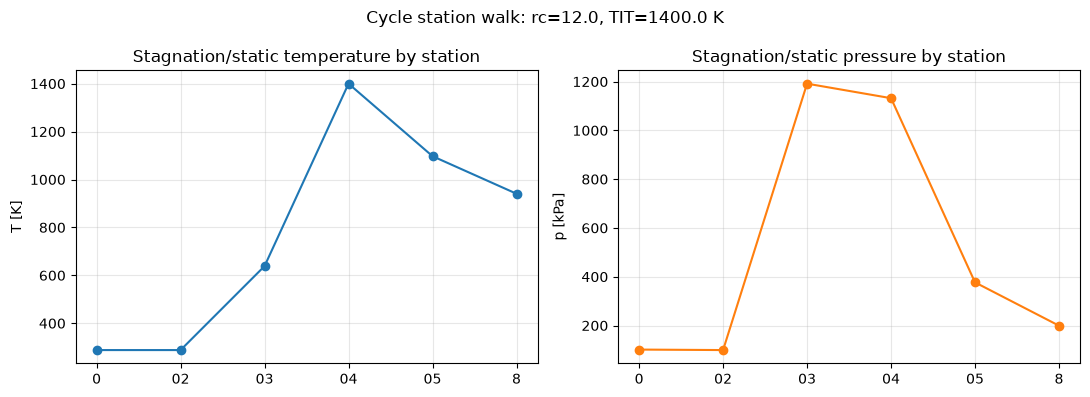

In [3]:
stations = ["0", "02", "03", "04", "05", "8"]
temps = [result.t0_k, result.t02_k, result.t03_k, result.t04_k, result.t05_k, result.t8_k]
pressures = [result.p0_pa, result.p02_pa, result.p03_pa, result.p04_pa, result.p05_pa, result.p8_pa]

fig, (ax_t, ax_p) = plt.subplots(1, 2, figsize=(11, 4))
ax_t.plot(stations, temps, marker="o")
ax_t.set_title("Stagnation/static temperature by station")
ax_t.set_ylabel("T [K]")
ax_t.grid(alpha=0.3)

ax_p.plot(stations, [p / 1000 for p in pressures], marker="o", color="tab:orange")
ax_p.set_title("Stagnation/static pressure by station")
ax_p.set_ylabel("p [kPa]")
ax_p.grid(alpha=0.3)
fig.suptitle(f"Cycle station walk: rc={design.compressor.pressure_ratio}, TIT={design.combustor.turbine_inlet_temp_k} K")
fig.tight_layout()
plt.show()

## 3. Static vs. cruise: propulsive efficiency only exists in motion

`eta_p = 0` at `V0 = 0` by definition (no thrust *power* is done on a
stationary vehicle). Sweeping Mach number at a fixed altitude shows
`eta_p` rise from zero as flight speed increases.

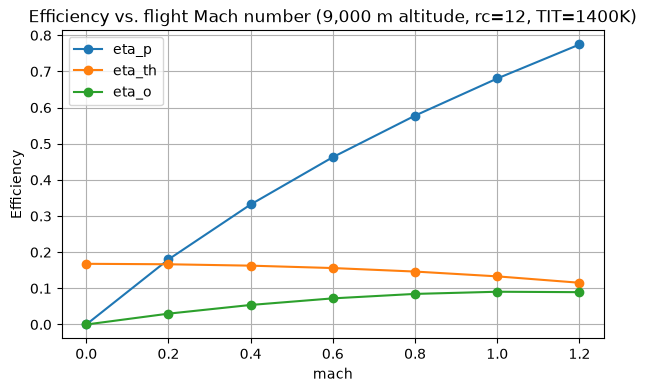

,mach,eta_p,eta_th,eta_o
0,0.0,0.000000,0.167873,0.000000
1,0.2,0.180051,0.166609,0.029998
2,0.4,0.332030,0.162759,0.054041
3,0.6,0.462933,0.156144,0.072284
4,0.8,0.577802,0.146441,0.084614
5,1.0,0.680529,0.133143,0.090608
6,1.2,0.774538,0.115488,0.089450


In [4]:
mach_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
records = []
for m in mach_values:
    r = engine.run(FlightCondition(altitude_m=9000.0, mach=m))
    records.append({"mach": m, "eta_p": r.propulsive_efficiency, "eta_th": r.thermal_efficiency, "eta_o": r.overall_efficiency})

eff_df = pd.DataFrame(records)
eff_df.plot(x="mach", y=["eta_p", "eta_th", "eta_o"], marker="o", figsize=(7, 4), grid=True)
plt.title("Efficiency vs. flight Mach number (9,000 m altitude, rc=12, TIT=1400K)")
plt.ylabel("Efficiency")
plt.show()
eff_df